Importación de librerias

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt  

Se carga el dataset

In [3]:
df = pd.read_csv("data/hotel_bookings.csv")

Dimensiones del dataset

In [4]:
filas, columnas = df.shape
print(f"Cantidad de filas: {filas}")
print(f"Cantidad de columnas: {columnas}")

Cantidad de filas: 119390
Cantidad de columnas: 32


In [5]:
# Ver todas las columnas
print("Columnas del dataset:\n")
print(df.columns)

Columnas del dataset:

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


Tipo y cantidad de registros por columna

In [6]:
# Subset primeras 16 columnas
primeras_16 = df.iloc[:, :16]

print("===== PRIMERAS 16 COLUMNAS =====\n")
print(primeras_16.info())

===== PRIMERAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   hotel                      119390 non-null  object 
 1   is_canceled                119390 non-null  int64  
 2   lead_time                  119390 non-null  int64  
 3   arrival_date_year          119390 non-null  int64  
 4   arrival_date_month         119390 non-null  object 
 5   arrival_date_week_number   119390 non-null  int64  
 6   arrival_date_day_of_month  119390 non-null  int64  
 7   stays_in_weekend_nights    119390 non-null  int64  
 8   stays_in_week_nights       119390 non-null  int64  
 9   adults                     119390 non-null  int64  
 10  children                   119386 non-null  float64
 11  babies                     119390 non-null  int64  
 12  meal                       119390 non-null  object 


In [7]:
# Subset últimas 16 columnas
ultimas_16 = df.iloc[:, 16:]

print("===== ÚLTIMAS 16 COLUMNAS =====\n")
print(ultimas_16.info())

===== ÚLTIMAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_repeated_guest               119390 non-null  int64  
 1   previous_cancellations          119390 non-null  int64  
 2   previous_bookings_not_canceled  119390 non-null  int64  
 3   reserved_room_type              119390 non-null  object 
 4   assigned_room_type              119390 non-null  object 
 5   booking_changes                 119390 non-null  int64  
 6   deposit_type                    119390 non-null  object 
 7   agent                           103050 non-null  float64
 8   company                         6797 non-null    float64
 9   days_in_waiting_list            119390 non-null  int64  
 10  customer_type                   119390 non-null  object 
 11  adr                             119390 non-nu

Nulos

In [8]:
#analisis de nulos primeras 16 columnas 
primeras_16 = df.iloc[:, :16]

print("Valores nulos por columna (primeras 16):\n")
print(primeras_16.isnull().sum())
total_nulos_primeras = primeras_16.isnull().sum().sum()
print("\nTotal de valores nulos en las primeras 16 columnas:", total_nulos_primeras)

Valores nulos por columna (primeras 16):

hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_year              0
arrival_date_month             0
arrival_date_week_number       0
arrival_date_day_of_month      0
stays_in_weekend_nights        0
stays_in_week_nights           0
adults                         0
children                       4
babies                         0
meal                           0
country                      488
market_segment                 0
distribution_channel           0
dtype: int64

Total de valores nulos en las primeras 16 columnas: 492


In [9]:
#analisis de nulos ultimas 16 columnas 

ultimas_16 = df.iloc[:, -16:]

print("\nValores nulos por columna (últimas 16):\n")
print(ultimas_16.isnull().sum())
total_nulos_ultimas = ultimas_16.isnull().sum().sum()
print("\nTotal de valores nulos en las últimas 16 columnas:", total_nulos_ultimas)



Valores nulos por columna (últimas 16):

is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
reservation_status_date                0
dtype: int64

Total de valores nulos en las últimas 16 columnas: 128933


Sustituimos los valores nulos en la variable "CHILDREN" y lo remplazamos por la mediana.

In [10]:
#se averigua la mediana para reemplazar los valores nulos en esa columna 
mediana_children = df['children'].median()
print("La mediana de children es:", mediana_children)

La mediana de children es: 0.0


In [11]:
# children: reemplazar nulos por 0 (si no hay niños)
df['children'] = df['children'].fillna(0)

Reemplazamos los nulos de la columna "COUNTRY" por desconocido 'Unknown'

In [12]:
df['country'] = df['country'].fillna('Unknown')

Reemplazamos los nulos de "AGENT" por 0 ya que es numerica la columna 

In [13]:
df['agent'] = df['agent'].fillna(0)

In [14]:
#se reemplazan los nan de la columna company por 0, ya que es de tipo float (con comapañia vs sin compañia)
df['company'] = df['company'].fillna(0)


In [15]:
#analisis de nulos primeras 16 columnas 
primeras_16 = df.iloc[:, :16]

print("Valores nulos por columna (primeras 16):\n")
print(primeras_16.isnull().sum())
total_nulos_primeras = primeras_16.isnull().sum().sum()
print("\nTotal de valores nulos en las primeras 16 columnas:", total_nulos_primeras)

Valores nulos por columna (primeras 16):

hotel                        0
is_canceled                  0
lead_time                    0
arrival_date_year            0
arrival_date_month           0
arrival_date_week_number     0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
children                     0
babies                       0
meal                         0
country                      0
market_segment               0
distribution_channel         0
dtype: int64

Total de valores nulos en las primeras 16 columnas: 0


In [16]:
#analisis de nulos ultimas 16 columnas 

ultimas_16 = df.iloc[:, -16:]

print("\nValores nulos por columna (últimas 16):\n")
print(ultimas_16.isnull().sum())
total_nulos_ultimas = ultimas_16.isnull().sum().sum()
print("\nTotal de valores nulos en las últimas 16 columnas:", total_nulos_ultimas)


Valores nulos por columna (últimas 16):

is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status                0
reservation_status_date           0
dtype: int64

Total de valores nulos en las últimas 16 columnas: 0


Filas duplicadas

In [17]:
# Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 31994


In [18]:
# Eliminamos filas duplicadas
df = df.drop_duplicates()

# Verificamos que se eliminaron
duplicados = df.duplicated().sum()
print(f"Filas duplicadas después de eliminar: {duplicados}")

Filas duplicadas después de eliminar: 0


In [19]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,81.004657,11.016809,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,109.945638,54.047484,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [20]:
# Se utiliza la funcion round para visualizar mejor los datos
df.describe().round()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0
mean,0.0,80.0,2016.0,27.0,16.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,81.0,11.0,1.0,106.0,0.0,1.0
std,0.0,86.0,1.0,14.0,9.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,110.0,54.0,10.0,55.0,0.0,1.0
min,0.0,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.0,0.0,0.0
25%,0.0,11.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,72.0,0.0,0.0
50%,0.0,49.0,2016.0,27.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,98.0,0.0,0.0
75%,1.0,125.0,2017.0,37.0,23.0,2.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,234.0,0.0,0.0,134.0,0.0,1.0
max,1.0,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0


Outliers

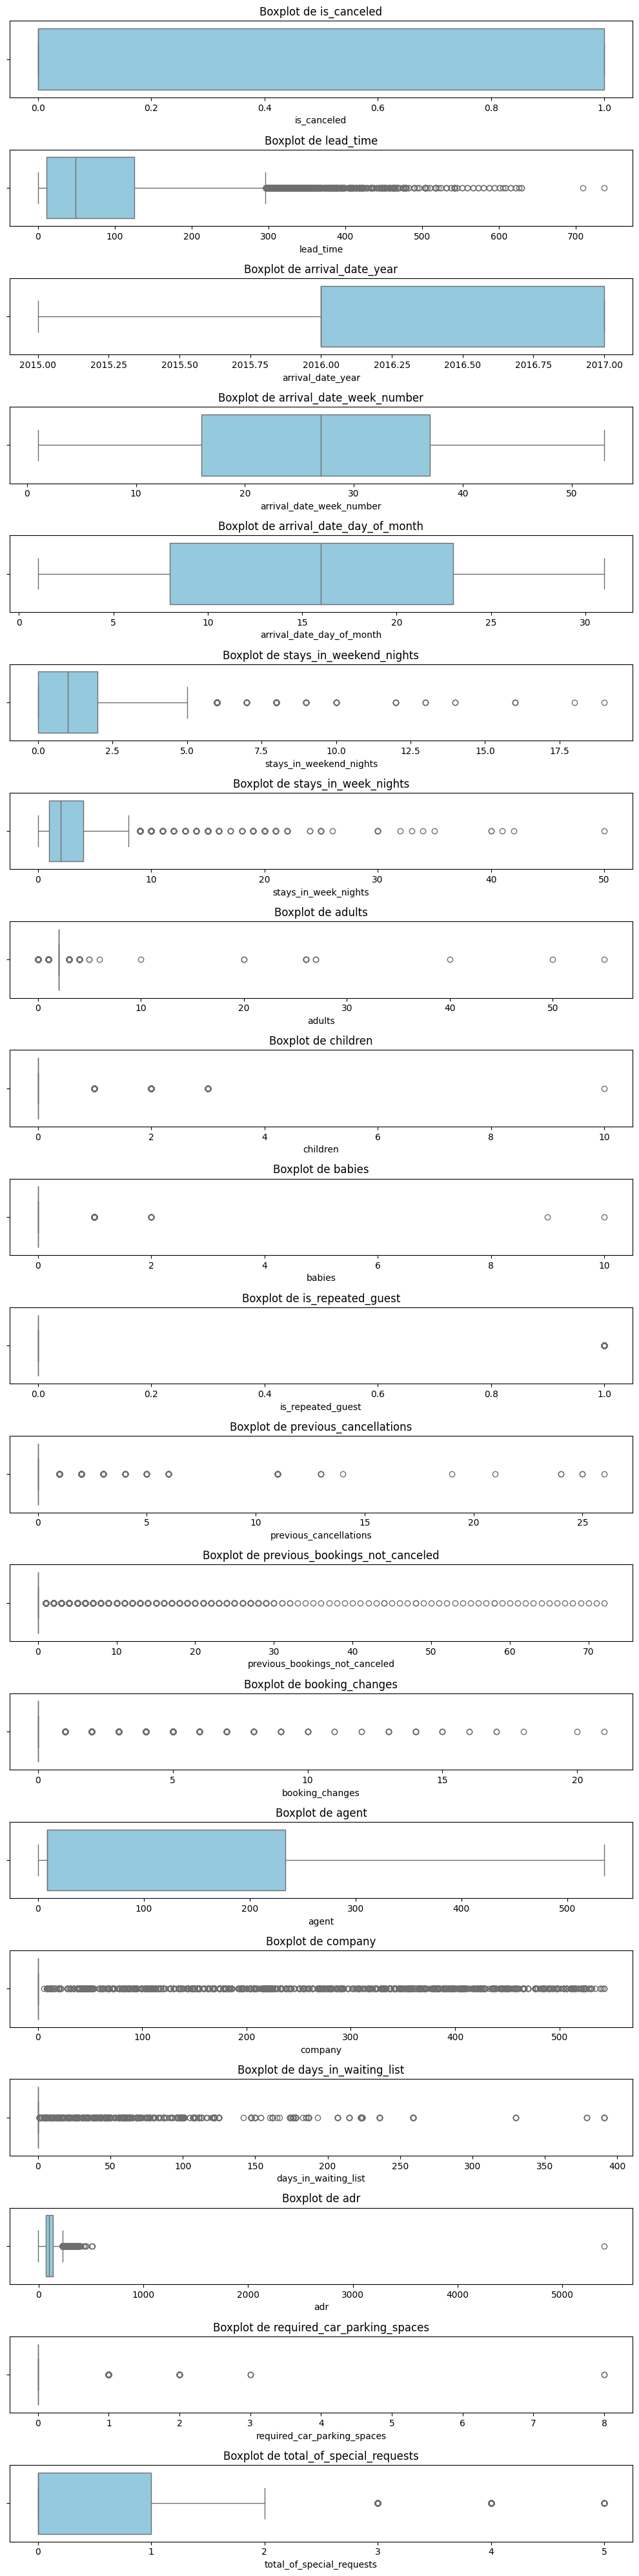

In [21]:
# Seleccionar automáticamente todas las columnas numéricas
num_vars = df.select_dtypes(include=["int64", "float64"]).columns

# Crear subplots dinámicos
fig, axes = plt.subplots(nrows=len(num_vars), ncols=1, figsize=(10, 2*len(num_vars)))

for i, col in enumerate(num_vars):
    sns.boxplot(x=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Correlaciones numericas

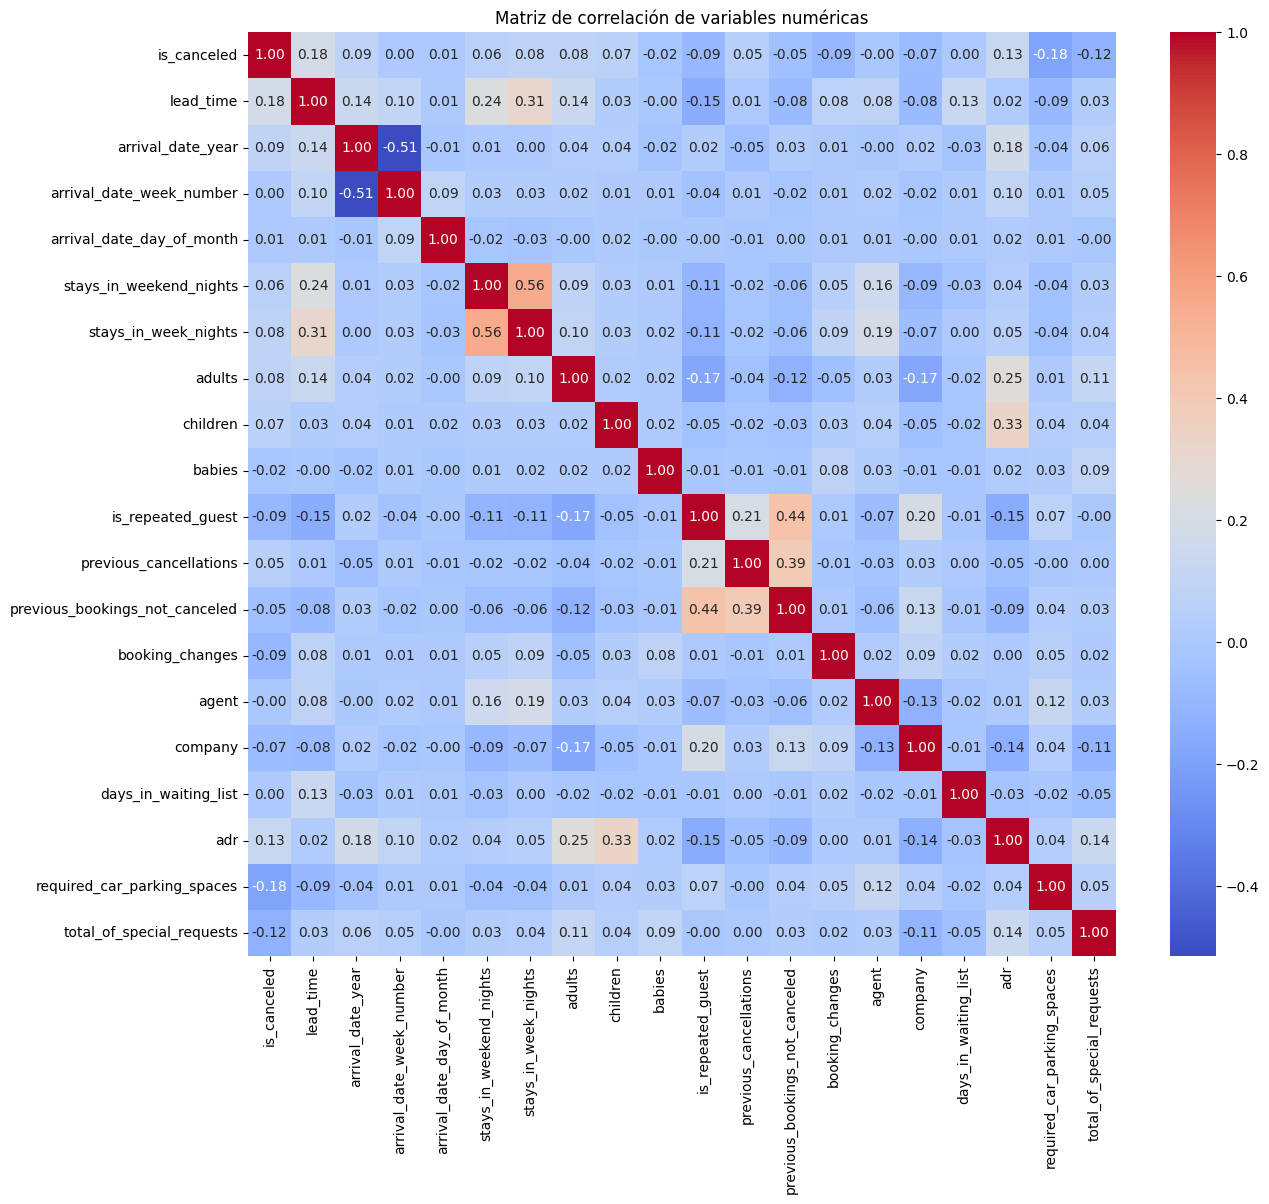

In [22]:
# Seleccionamos solo las columnas numéricas automáticamente
numeric_df = df.select_dtypes(include='number')

# Matriz de correlación
corr_matrix = numeric_df.corr()

# Mapa de calor
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación de variables numéricas')
plt.show()

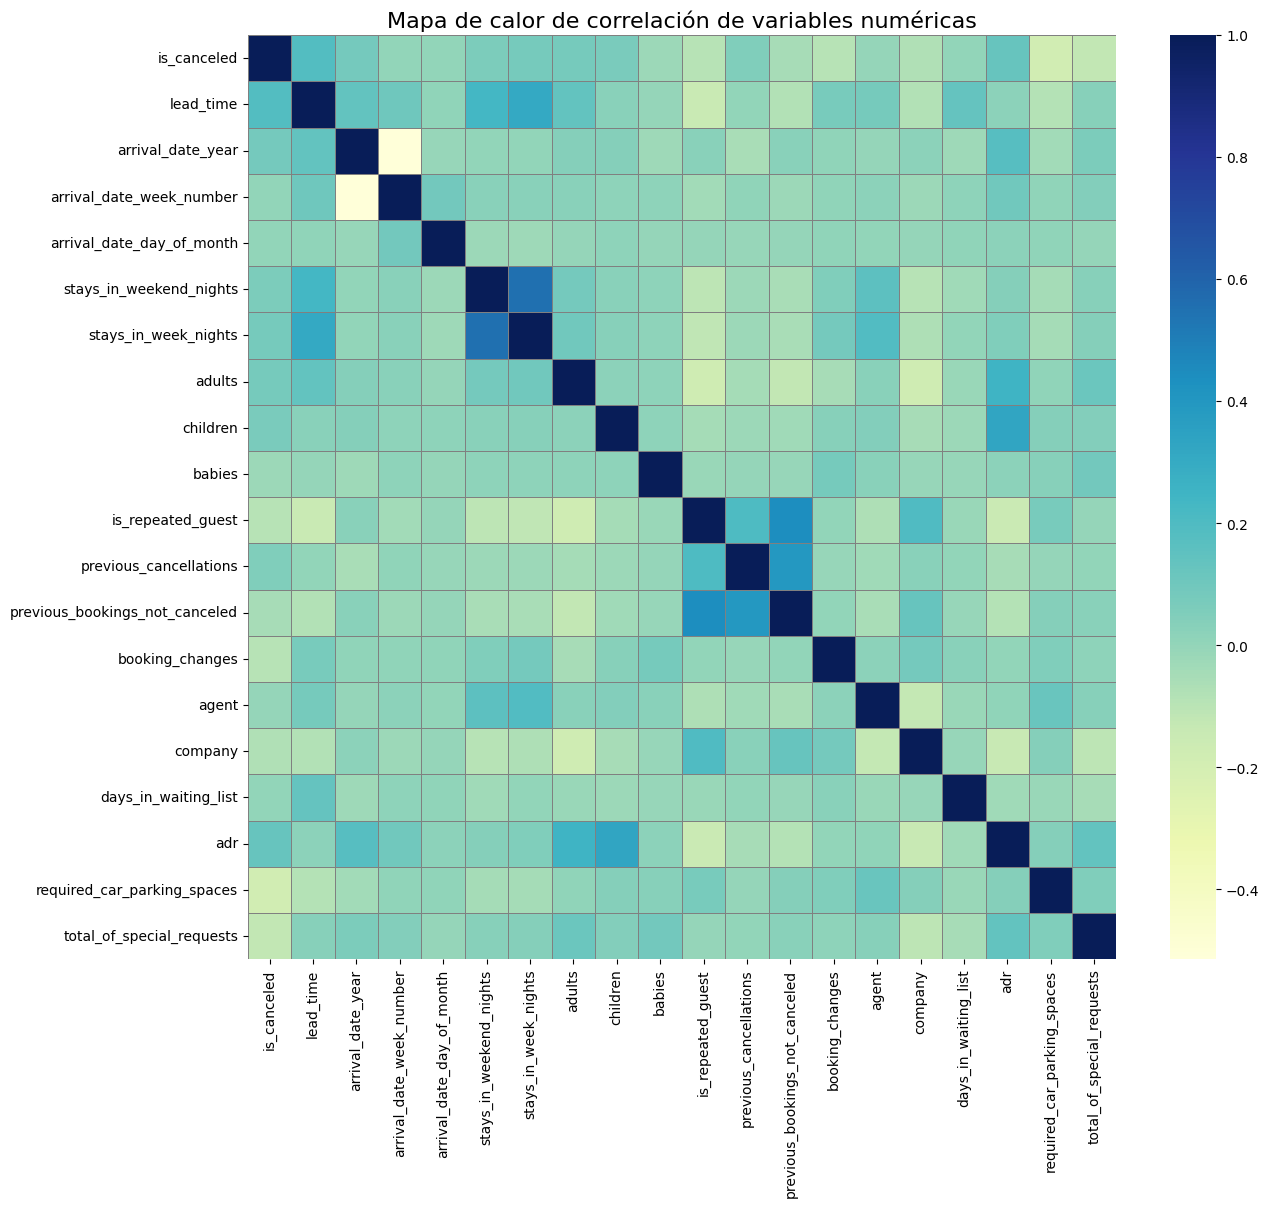

In [23]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Dibujar mapa de calor más visual
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Mapa de calor de correlación de variables numéricas', fontsize=16)
plt.show()

A partir de la pregunta : ¿Cómo varía la distribución mensual de reservas entre city hotel y resort hotel,
y qué patrones de estacionalidad se observan?
Realizamos un grafico de barras para tener una respuesta anticipada.

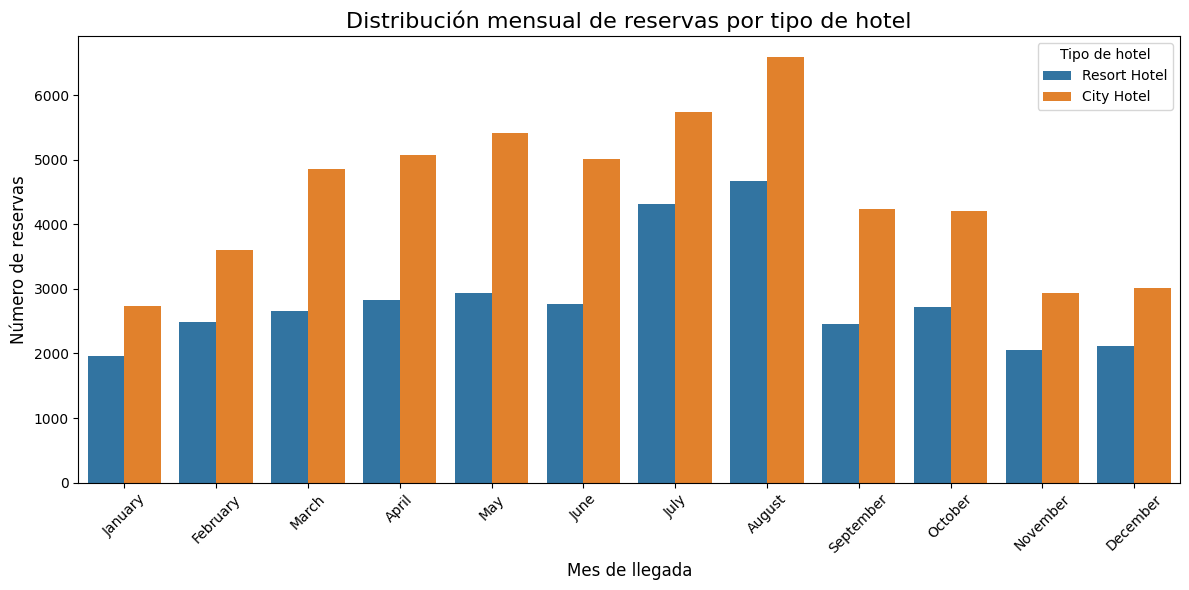

In [24]:
# Asegurar que los meses queden en orden cronológico
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Gráfico de barras agrupadas
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="arrival_date_month", hue="hotel", order=month_order)

plt.title("Distribución mensual de reservas por tipo de hotel", fontsize=16)
plt.xlabel("Mes de llegada", fontsize=12)
plt.ylabel("Número de reservas", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Tipo de hotel")
plt.tight_layout()
plt.show()

¿Cómo se distribuye el lead_time (días entre la reserva y la llegada), y qué
relación tiene con la probabilidad de cancelación?


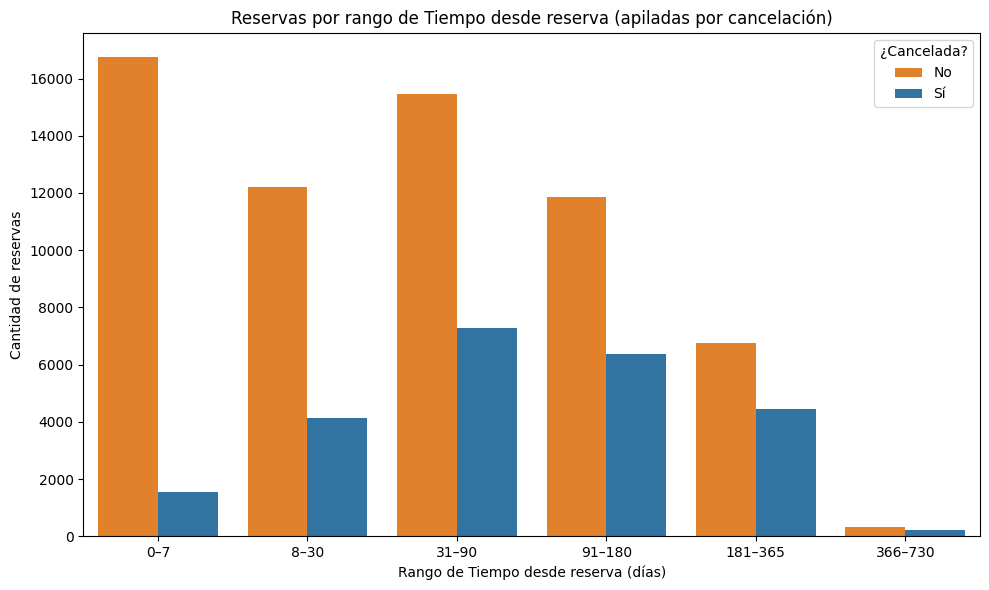

In [25]:
df = df.copy()
df = df[df["lead_time"].notna()]

# === Definir rangos de lead_time ===
# Pensados para separar bien corto, medio y MUY anticipado
bins = [0, 7, 30, 90, 180, 365, 730]  # 0-1 semana, 8-30d, 31-90d, 91-180d, 181-365d, 366-730d
labels = [
    "0–7",
    "8–30",
    "31–90",
    "91–180",
    "181–365",
    "366–730"
]

df["lead_time_bin"] = pd.cut(df["lead_time"], bins=bins, labels=labels, right=True, include_lowest=True)
df = df[df["lead_time_bin"].notna()]  # por si hay fuera de rango

# Asegurar orden en el eje X
df["lead_time_bin"] = pd.Categorical(df["lead_time_bin"], categories=labels, ordered=True)

# === 1) Barras apiladas: volumen por rango (cancelada vs no) ===
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="lead_time_bin",
    hue="is_canceled",
    hue_order=[0,1],                              # 0=No, 1=Sí
    palette={0: "tab:orange", 1: "tab:blue"}     # Colores fijos para no confundir
)
plt.title("Reservas por rango de Tiempo desde reserva (apiladas por cancelación)")
plt.xlabel("Rango de Tiempo desde reserva (días)")
plt.ylabel("Cantidad de reservas")
plt.legend(title="¿Cancelada?", labels=["No","Sí"])
plt.tight_layout()
plt.show()




¿Qué segmentos de mercado (market_segment) y canales de distribución
(distribution_channel) concentran más reservas y cuáles presentan mayor
proporción de cancelaciones?

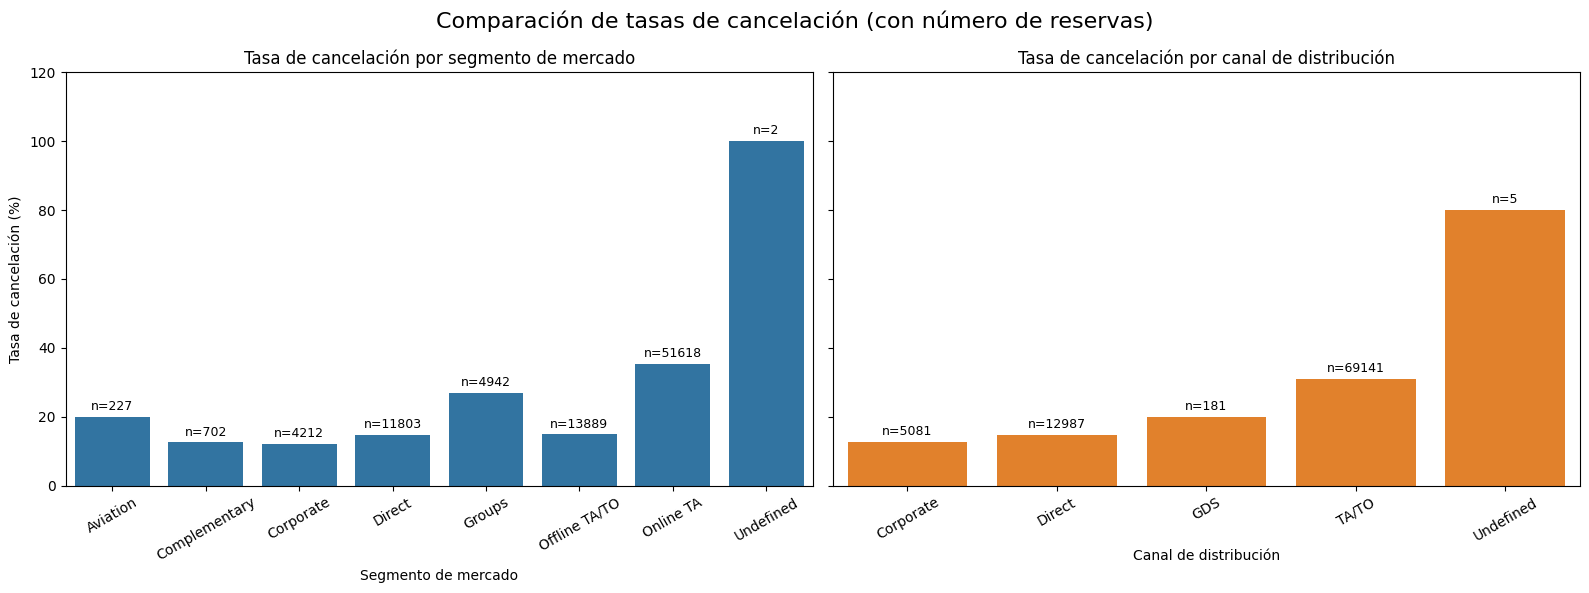

In [26]:
# === Calcular tasas y cantidades por segmento y canal ===
cancel_rate_seg = (
    df.groupby("market_segment")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
cancel_rate_seg["tasa_cancelacion"] *= 100

cancel_rate_chan = (
    df.groupby("distribution_channel")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
cancel_rate_chan["tasa_cancelacion"] *= 100

# === Crear figura con 2 subplots lado a lado ===
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# --- Panel 1: market_segment ---
sns.barplot(
    data=cancel_rate_seg,
    x="market_segment", y="tasa_cancelacion",
    color="tab:blue", ax=axes[0]
)
axes[0].set_title("Tasa de cancelación por segmento de mercado")
axes[0].set_xlabel("Segmento de mercado")
axes[0].set_ylabel("Tasa de cancelación (%)")
axes[0].set_ylim(0, 120)
axes[0].tick_params(axis='x', rotation=30)

# Anotar valores de cantidad de reservas
for i, row in cancel_rate_seg.iterrows():
    axes[0].text(
        i, row["tasa_cancelacion"] + 2,   # posición sobre la barra
        f'n={row["n_reservas"]}',         # texto
        ha="center", fontsize=9, color="black"
    )

# --- Panel 2: distribution_channel ---
sns.barplot(
    data=cancel_rate_chan,
    x="distribution_channel", y="tasa_cancelacion",
    color="tab:orange", ax=axes[1]
)
axes[1].set_title("Tasa de cancelación por canal de distribución")
axes[1].set_xlabel("Canal de distribución")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=30)

# Anotar valores de cantidad de reservas
for i, row in cancel_rate_chan.iterrows():
    axes[1].text(
        i, row["tasa_cancelacion"] + 2,
        f'n={row["n_reservas"]}',
        ha="center", fontsize=9, color="black"
    )

plt.suptitle("Comparación de tasas de cancelación (con número de reservas)", fontsize=16)
plt.tight_layout()
plt.show()

¿Qué países de origen generan mayor volumen de reservas y cuál es su tasa
relativa de cancelación?

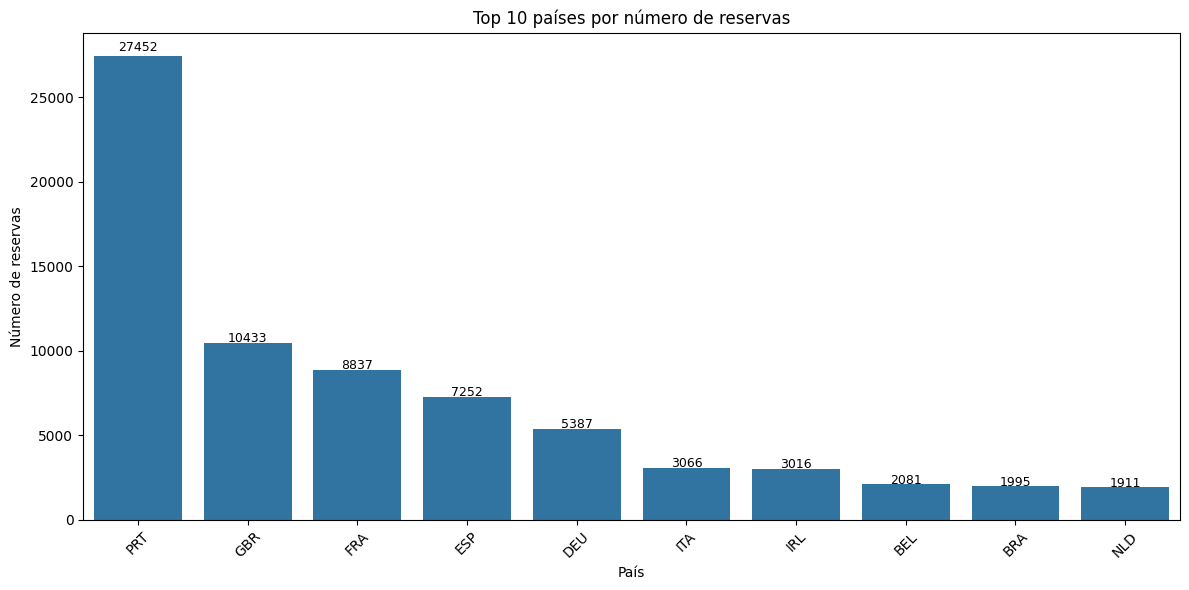

NameError: name 'top_countries' is not defined

<Figure size 1200x600 with 0 Axes>

In [27]:
# === Agrupar por país ===
country_stats = (
    df.groupby("country")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
country_stats["tasa_cancelacion"] *= 100  # convertir a %

# --- 1) Top 10 países por número de reservas ---
top_by_reservas = country_stats.sort_values("n_reservas", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_by_reservas,
    x="country", y="n_reservas",
    color="tab:blue"
)

# Etiquetas arriba
for i, row in enumerate(top_by_reservas.itertuples()):
    plt.text(i, row.n_reservas + (row.n_reservas*0.01),
             f'{row.n_reservas}', ha="center", fontsize=9)

plt.title("Top 10 países por número de reservas")
plt.xlabel("País")
plt.ylabel("Número de reservas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2) Tasa de cancelación SOLO en esos 10 países ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_countries,
    x="country", y="tasa_cancelacion",
    color="tab:orange"
)

# Etiquetas arriba
for i, row in enumerate(top_countries.itertuples()):
    plt.text(i, row.tasa_cancelacion + 1,
             f'{row.tasa_cancelacion:.1f}%', ha="center", fontsize=9)

plt.title("Tasa de cancelación (%) en los Top 10 países con más reservas")
plt.xlabel("País")
plt.ylabel("Tasa de cancelación (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Cómo se distribuye la duración de la estancia y qué diferencias existen entre city hotel y resort hotel?

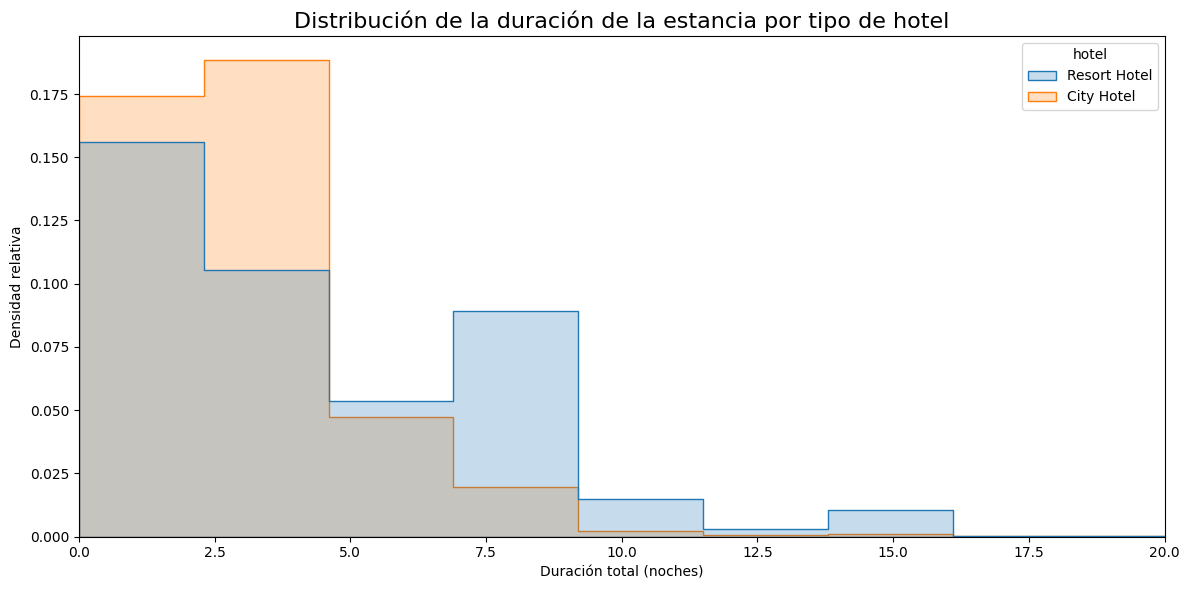

In [ ]:
# Crear columna de duración total
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Histograma comparativo
plt.figure(figsize=(12,6))
sns.histplot(
    data=df,
    x="total_stay",
    hue="hotel",
    bins=30,
    kde=False,
    element="step",
    stat="density",   # proporciones en vez de conteos
    common_norm=False # cada hotel se normaliza por separado
)

plt.title("Distribución de la duración de la estancia por tipo de hotel", fontsize=16)
plt.xlabel("Duración total (noches)")
plt.ylabel("Densidad relativa")
plt.xlim(0, 20)  # limitar a estancias comunes
plt.tight_layout()
plt.show()

¿Cuál es la evolución del ADR (tarifa diaria promedio) por mes y por tipo de
hotel, y cómo se refleja en temporada alta vs baja?

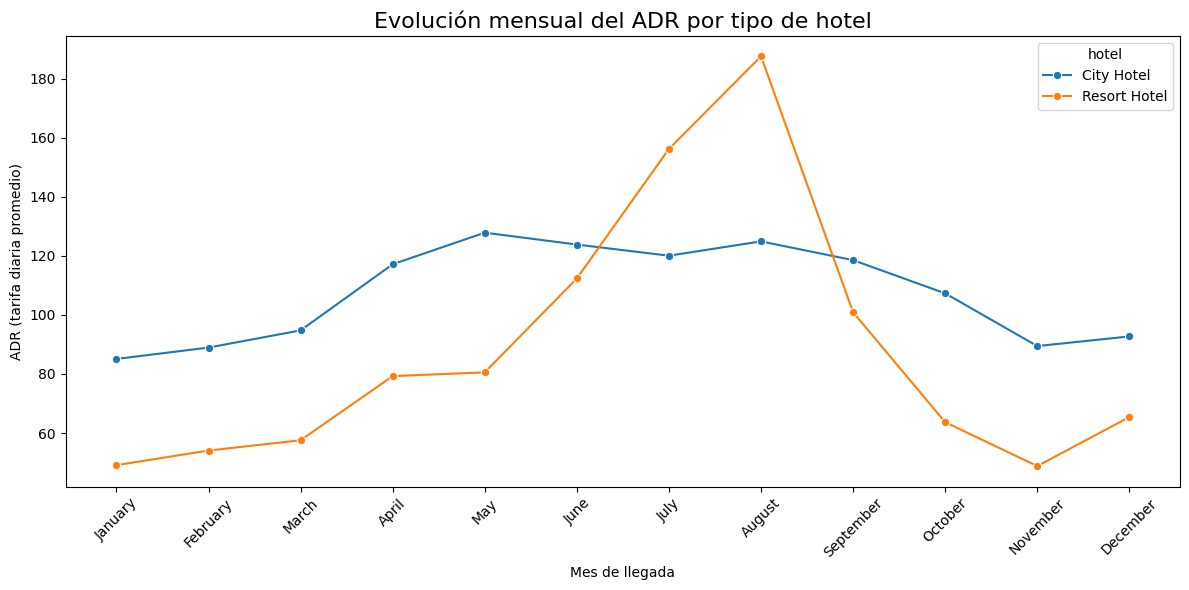

In [ ]:
# Asegurar orden correcto de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Agrupar por mes y hotel para calcular ADR promedio
adr_monthly = (
    df.groupby(["arrival_date_month","hotel"])["adr"]
      .mean()
      .reset_index()
)

# Convertir a categórico ordenado para respetar orden cronológico
adr_monthly["arrival_date_month"] = pd.Categorical(
    adr_monthly["arrival_date_month"], categories=month_order, ordered=True
)

# Gráfico de líneas
plt.figure(figsize=(12,6))
sns.lineplot(
    data=adr_monthly,
    x="arrival_date_month", y="adr",
    hue="hotel", marker="o"
)

plt.title("Evolución mensual del ADR por tipo de hotel", fontsize=16)
plt.xlabel("Mes de llegada")
plt.ylabel("ADR (tarifa diaria promedio)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

¿Cuál es la proporción de huéspedes según composición (adultos, niños y
bebés) y cómo varía entre meses?

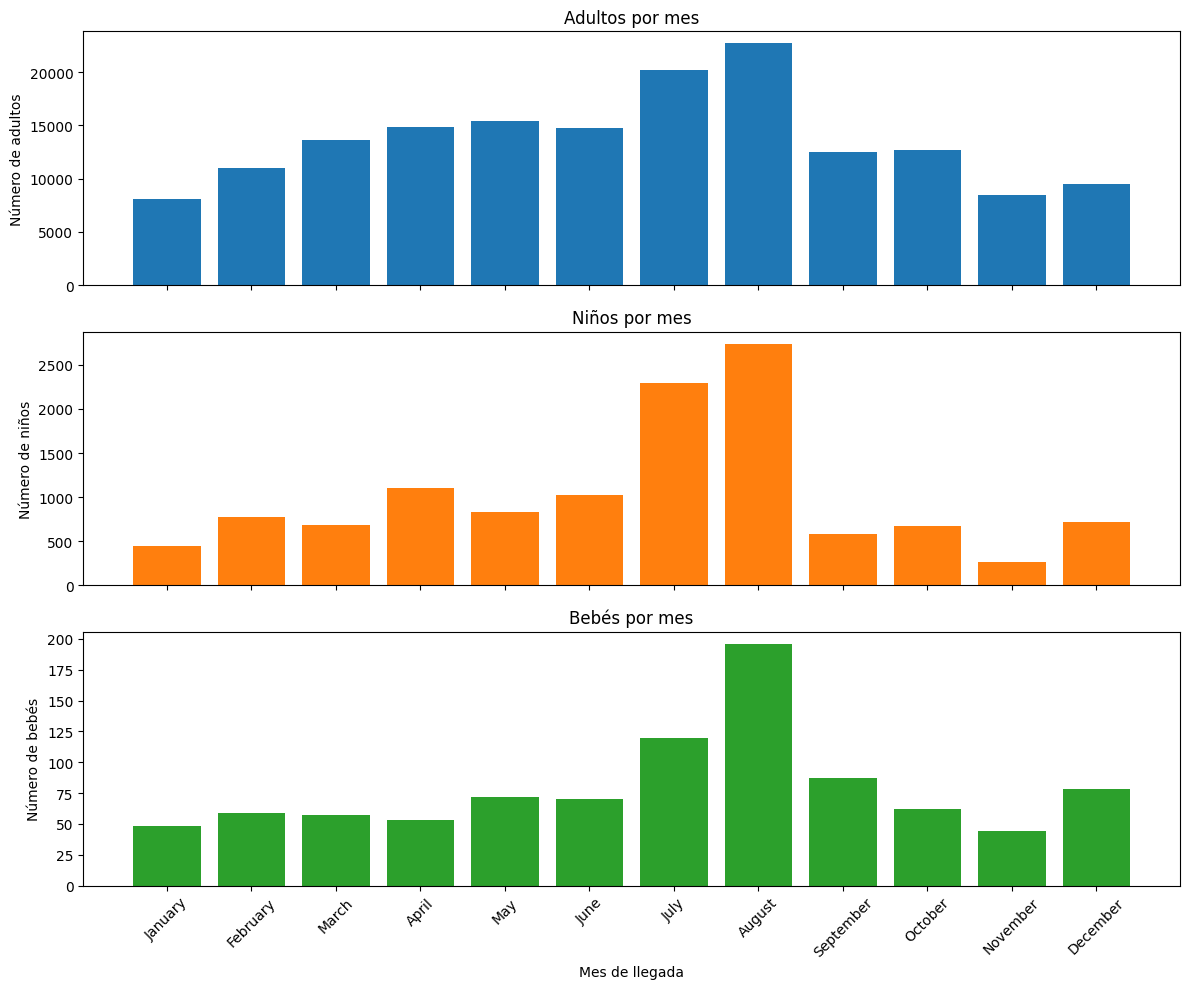

In [ ]:
# Orden cronológico de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Agrupar por mes
guests_monthly = (
    df.groupby("arrival_date_month")[["adults","children","babies"]]
      .sum()
      .reindex(month_order)
)

# Crear subplots
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

# --- Adultos ---
axes[0].bar(guests_monthly.index, guests_monthly["adults"], color="tab:blue")
axes[0].set_title("Adultos por mes")
axes[0].set_ylabel("Número de adultos")

# --- Niños ---
axes[1].bar(guests_monthly.index, guests_monthly["children"], color="tab:orange")
axes[1].set_title("Niños por mes")
axes[1].set_ylabel("Número de niños")

# --- Bebés ---
axes[2].bar(guests_monthly.index, guests_monthly["babies"], color="tab:green")
axes[2].set_title("Bebés por mes")
axes[2].set_ylabel("Número de bebés")
axes[2].set_xlabel("Mes de llegada")

# Ajustar etiquetas
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

¿Qué proporción de reservas corresponde a clientes recurrentes
(is_repeated_guest) y cómo impacta en las cancelaciones?

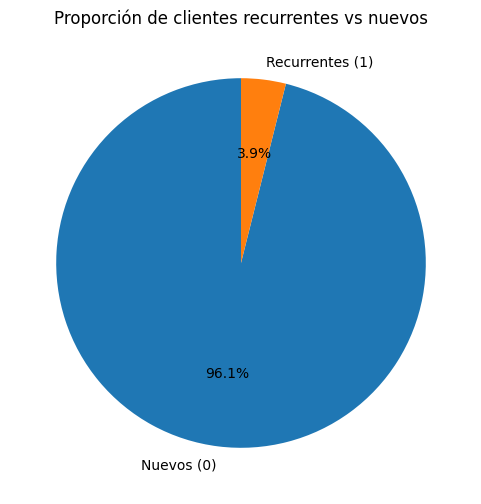

C:\Users\usuario\AppData\Local\Temp\ipykernel_5692\1524090863.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_rate, x="is_repeated_guest", y="is_canceled", palette="Set2")


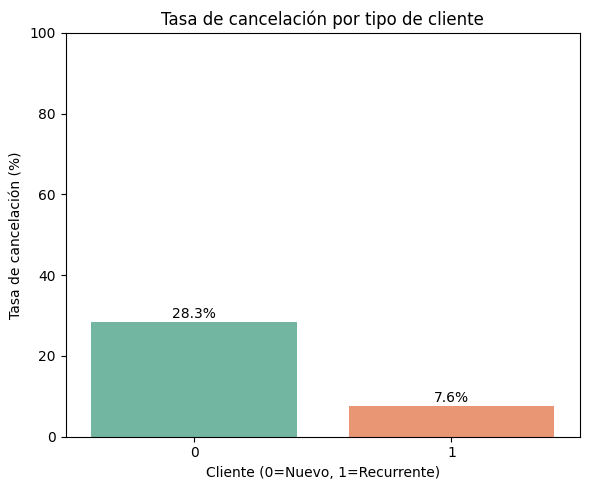

In [ ]:
# --- 1) Proporción de clientes recurrentes vs nuevos ---
repeated_counts = df["is_repeated_guest"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(repeated_counts, labels=["Nuevos (0)", "Recurrentes (1)"], 
        autopct="%1.1f%%", colors=["tab:blue","tab:orange"], startangle=90)
plt.title("Proporción de clientes recurrentes vs nuevos")
plt.show()

# --- 2) Tasa de cancelación por tipo de cliente ---
cancel_rate = (
    df.groupby("is_repeated_guest")["is_canceled"]
      .mean()
      .reset_index()
)
cancel_rate["is_canceled"] *= 100  # convertir a %

plt.figure(figsize=(6,5))
sns.barplot(data=cancel_rate, x="is_repeated_guest", y="is_canceled", palette="Set2")
plt.title("Tasa de cancelación por tipo de cliente")
plt.xlabel("Cliente (0=Nuevo, 1=Recurrente)")
plt.ylabel("Tasa de cancelación (%)")

# Etiquetas arriba
for i, row in cancel_rate.iterrows():
    plt.text(i, row.is_canceled + 1, f"{row.is_canceled:.1f}%", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# Columnas categóricas primeras 10
cat_cols = df.select_dtypes(include=['object']).columns

# Tomar solo las primeras 10 columnas (o menos si hay menos de 10)
primeras_10 = cat_cols[:10]

# Mostrar cada columna y su distribución de valores
for col in primeras_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())




Columna: hotel


hotel
City Hotel      53428
Resort Hotel    33967
Name: count, dtype: int64


Columna: arrival_date_month


arrival_date_month
August       11257
July         10056
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64


Columna: meal


...

assigned_room_type
A    46313
D    22432
E     7195
F     3627
G     2498
C     2164
B     1820
H      706
I      357
K      276
P        6
L        1
Name: count, dtype: int64


Columna: deposit_type


deposit_type
No Deposit    86250
Non Refund     1038
Refundable      107
Name: count, dtype: int64


Columna: customer_type


customer_type
Transient          71985
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64

In [ ]:
# Columnas categóricas 1
cat_cols = df.select_dtypes(include=['object']).columns

# Excluir reservation_status_date
cat_cols_sin_fecha = [col for col in cat_cols if col != 'reservation_status_date']

# Tomar las columnas de la 11 a la 20 (máximo 10)
siguientes_10 = cat_cols_sin_fecha[10:20]

# Mostrar cada columna y su distribución de valores
for col in siguientes_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())



Columna: reservation_status


reservation_status
Check-Out    63370
Canceled     23011
No-Show       1014
Name: count, dtype: int64

In [ ]:
# Convertir a datetime 1
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Conteo por año
print("\nConteo por año:")
display(df['reservation_status_date'].dt.year.value_counts().sort_index())

# Conteo por mes
print("\nConteo por mes:")
display(df['reservation_status_date'].dt.month.value_counts().sort_index())

# Conteo por día de la semana
print("\nConteo por día de la semana (0=Lunes, 6=Domingo):")
display(df['reservation_status_date'].dt.dayofweek.value_counts().sort_index())



Conteo por año:


reservation_status_date
2014       12
2015    13546
2016    43927
2017    29910
Name: count, dtype: int64


Conteo por mes:


reservation_status_date
1     6490
2     7054
3     8158
4     7831
5     8197
6     7366
7     8839
8     9268
9     6917
10    6858
11    5634
12    4783
Name: count, dtype: int64


Conteo por día de la semana (0=Lunes, 6=Domingo):


reservation_status_date
0    13196
1    11701
2    12178
3    13414
4    13076
5    10697
6    13133
Name: count, dtype: int64

In [ ]:
# Año mínimo y máximo
print("Rango de años:", df['arrival_date_year'].min(), "-", df['arrival_date_year'].max())

# Meses distintos
print("Meses presentes:", df['arrival_date_month'].unique())


Rango de años: 2015 - 2017
Meses presentes: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']


In [ ]:
# ============================================================
# SVM REGRESIÓN (SVR) COMPLETO — Ocupación mensual por hotel
# ============================================================

# 0) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Asegurar numéricos en columnas que vamos a promediar
num_cols = [
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Orden natural de meses (por si viene como texto)
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=month_order, ordered=True)

# 2) Construir dataset mensual (target = ocupación mensual, conteo de reservas)
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocup = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")
)

agg = (
    df.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

data = ocup.merge(agg, on=group_cols, how="inner")

# Codificaciones generales
data["month_num"] = data["arrival_date_month"].cat.codes + 1
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

# hotel -> 0/1 (macro, no micro variables de cliente)
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1})

# ---------------------------
# 3) DEFINIR FEATURES Y TARGET
# ---------------------------
# Variables GENERALES (macro) coherentes con ocupación mensual
features = [
    "hotel","arrival_date_year","month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
target = "ocupacion"

model_df = data[features + [target]].dropna().copy()
X = model_df[features]
y = model_df[target]

# ------------------------------
# 4) SPLIT + ESCALADO (X e y)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalamos X (siempre para SVR)
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Escalamos y (MUY recomendable en SVR)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

# ------------------------------------
# 5) ENTRENAMIENTO BÁSICO (SVR RBF)
# ------------------------------------
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.2)
svr.fit(X_train_sc, y_train_sc)

# Predicción + desescalado de y
y_pred_sc = svr.predict(X_test_sc)
y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()

r2_base = r2_score(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"SVR (base) -> R²: {r2_base:.3f} | RMSE: {rmse_base:.1f}")

# ------------------------------------
# 6) TUNING AUTOMÁTICO (GridSearchCV)
# ------------------------------------
# Rango compacto y razonable; podés ampliarlo si querés
param_grid = {
    "C": [10, 30, 100, 300, 1000],
    "gamma": ["scale", 0.3, 0.1, 0.03, 0.01],
    "epsilon": [0.05, 0.1, 0.2, 0.3]
}
grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_sc, y_train_sc)

best_svr = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)

# Re-entrenar con el mejor modelo y evaluar
y_pred_sc_best = best_svr.predict(X_test_sc)
y_pred_best = scaler_y.inverse_transform(y_pred_sc_best.reshape(-1,1)).ravel()

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"SVR (best) -> R²: {r2_best:.3f} | RMSE: {rmse_best:.1f}")

# ------------------------------------
# 7) GRÁFICOS DE DIAGNÓSTICO
# ------------------------------------
# Real vs Predicho
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Ocupación real")
plt.ylabel("Ocupación predicha")
plt.title("SVR (mejor modelo) — Real vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuales
resid = y_test - y_pred_best
plt.figure(figsize=(7,4))
plt.scatter(y_pred_best, resid, alpha=0.5)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicho")
plt.ylabel("Residual (Real - Predicho)")
plt.title("SVR — Residuales vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------
# 8) FUNCIÓN DE PREDICCIÓN MANUAL
# ------------------------------------
def predecir_ocupacion_svr(registro_dict):
    """
    registro_dict: dict con las mismas claves que 'features'.
    Ejemplo:
      {
        "hotel": 1, "arrival_date_year": 2017, "month_num": 1,
        "lead_time": 75, "adr": 135.0,
        "stays_in_week_nights": 3, "stays_in_weekend_nights": 2,
        "total_of_special_requests": 1
      }
    """
    row = pd.DataFrame([registro_dict])[features]
    row_sc = scaler_X.transform(row)
    y_sc = best_svr.predict(row_sc).reshape(-1,1)
    y_hat = scaler_y.inverse_transform(y_sc).ravel()[0]
    # Evitar negativos (ocupación no puede ser negativa)
    return max(y_hat, 0.0)

# Ejemplo de uso:
ejemplo = {
    "hotel": 1,                      # 0=City, 1=Resort
    "arrival_date_year": 2017,
    "month_num": 1,                  # Enero
    "lead_time": 80,
    "adr": 140.0,
    "stays_in_week_nights": 3.0,
    "stays_in_weekend_nights": 2.0,
    "total_of_special_requests": 1.0
}
pred = predecir_ocupacion_svr(ejemplo)
print(f"\n🎯 Predicción SVR (ejemplo manual): {pred:.0f} reservas/mes")

NameError: name 'df' is not defined